In [2]:
#import

import torch 
import numpy as np

alpha = drwas samples form a beta distribution 



In [3]:

def mixup_data(x, y, alpha=1):

    mixup_coeff = np.random.beta(alpha, alpha) if alpha>0 else 1
    index = torch.randperm(x.size()[0]).to(x.device)

    mixed_x = mixup_coeff * x + (1 - mixup_coeff) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, mixup_coeff

lam: 0.6370276517927543
Mixed WMH image: tensor([[[[-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          ...,
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841]],

         [[-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          ...,
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841],
          [-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841, -2.4841]],

         [[-2.4841, -2.4841, -2.4841,  ..., -2.4841, -2.4841,

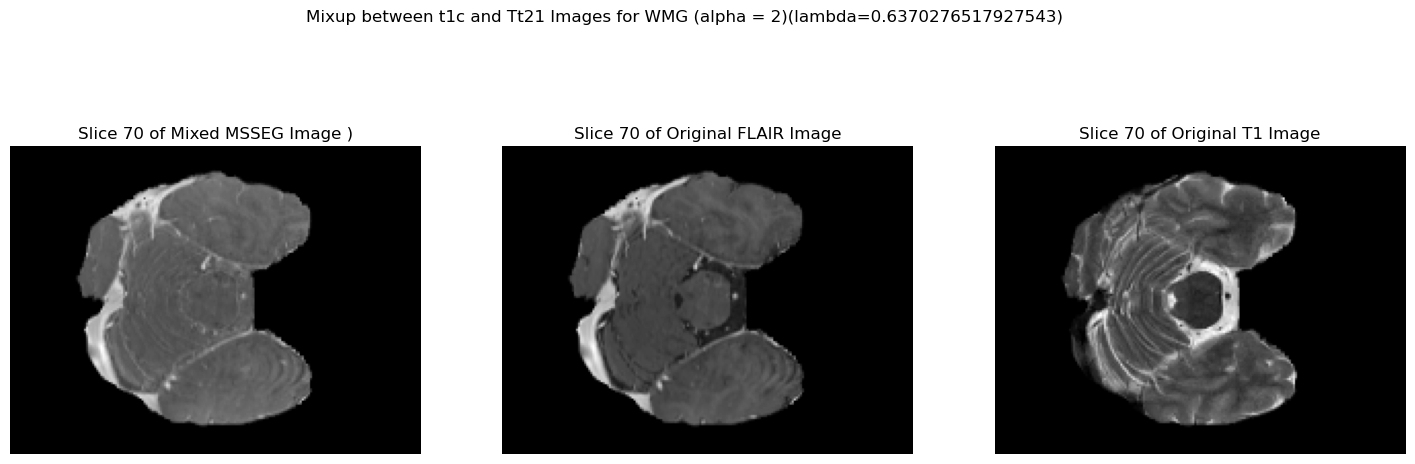

In [64]:
import nibabel as nib
import torch
import numpy as np

# original implementation mixup





def mixup_data(x:torch.tensor, alpha=2):
    """Returns mixed inputs, pairs of targets, and lambda"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
        print("lam:", lam)
    else:
        lam = 1
        # if lam is 1 then mixed image same as one of the images and if 
        # 0 then its the same as other image,
        # do not want this so set a range e.g. between 0.2 and 0.8 for example. 
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x[index[0]] + (1 - lam) * x[index[1]]
    mixed_x = mixed_x.unsqueeze(0)
    return mixed_x, lam



# Load a NIfTI image from the WMH dataset

# Assuming the path to the NIfTI file is 'wmh_image.nii.gz'
wmh_image_path =  'data/MSSEG/Images/test_c03_p03.nii.gz'   # 'data/WMH/Images/train_23_u.nii.gz'
wmh_image_nifti = nib.load(wmh_image_path)
wmh_image_data = wmh_image_nifti.get_fdata()

# Convert the NIfTI image data to a tensor
wmh_image_tensor = torch.tensor(
    wmh_image_data, dtype=torch.float32
)  # Add batch dimension
wmh_image_tensor1 = wmh_image_tensor.permute(
    3, 0, 1, 2
)  # Change the order of dimensions to (C, H, W, D)
wmh_flair = wmh_image_tensor1[2].unsqueeze(0)
wmh_t1 = wmh_image_tensor1[3].unsqueeze(0)

wmh_image_tensor_1= wmh_image_tensor1[[2,3],:,:,:]

# Mixup between the two channels
mixed_wmh_image, lam = mixup_data(wmh_image_tensor_1, alpha=2)

print("Mixed WMH image:", mixed_wmh_image)

alpha = 2

# label

label_path = "data/WMH/Labels/train_0_u.nii.gz"
label_nifti = nib.load(label_path)
label_data = label_nifti.get_fdata()


#Apply mixup to FLAIR and T1 modalities

# PRINT MIXED IMAGE

import matplotlib.pyplot as plt

# Select a slice to visualize
slice_index = 70

# Create a subplot for all three images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# plot title of the subplot
fig.suptitle(f"Mixup between t1c and Tt21 Images for WMG (alpha = {alpha})(lambda={lam})")

# Plot the slice of the mixed image




axes[0].imshow(mixed_wmh_image[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[0].set_title(f"Slice {slice_index} of Mixed MSSEG Image )")
axes[0].axis("off")


# Plot the slice of the original FLAIR image
axes[1].imshow(wmh_flair[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[1].set_title(f"Slice {slice_index} of Original FLAIR Image")
axes[1].axis("off")

# Plot the slice of the original T1 image
axes[2].imshow(wmh_t1[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[2].set_title(f"Slice {slice_index} of Original T1 Image")
axes[2].axis("off")

plt.show()





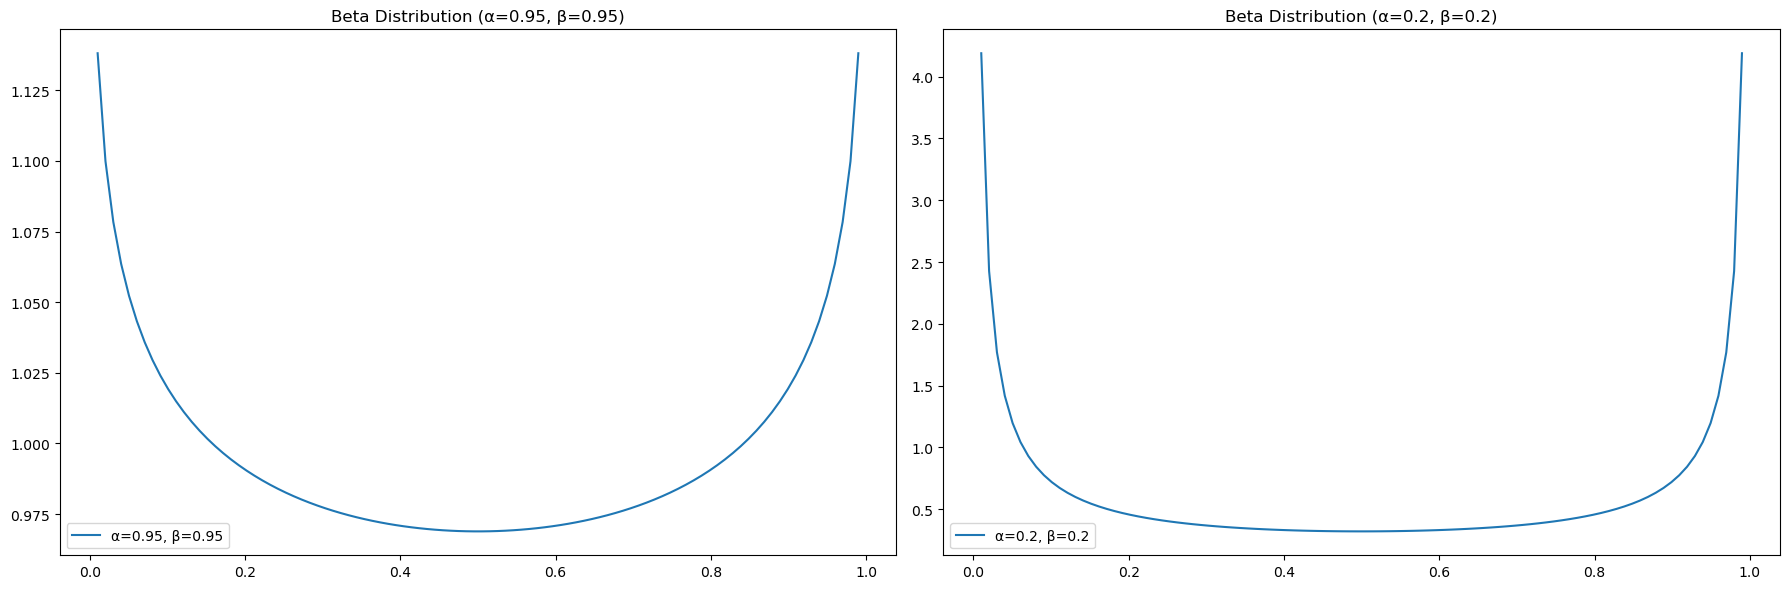

In [6]:
# Plot different beta distributions for various alpha and beta values
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define alpha and beta values
alpha_values =[0.95,0.2]   #[0.1,0.2,0.5, 1, 2, 5,10,20]


# Create a range of x values from 0 to 1
x = np.linspace(0, 1, 100)

# Create a subplot for each alpha value (since alpha and beta are the same)
fig, axes = plt.subplots(1, len(alpha_values), figsize=(18, 6))

for i, alpha in enumerate(alpha_values):
    y = beta.pdf(x, alpha,alpha)
    axes[i].plot(x, y, label=f'α={alpha}, β={alpha}')
    axes[i].set_title(f'Beta Distribution (α={alpha}, β={alpha})')
    axes[i].legend()

plt.tight_layout()
plt.show()


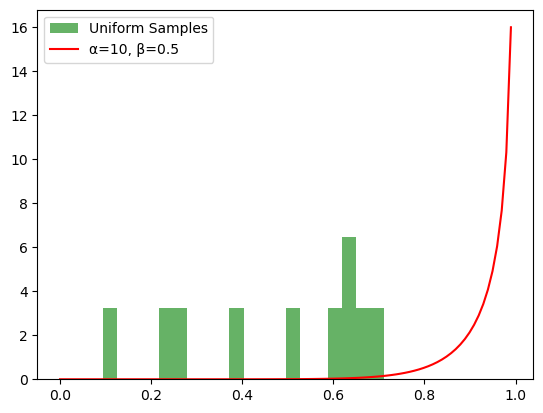

In [7]:
# dropped and existing sample:
# uniformly choose sample between 0 and 0.8 and never choose between 0.8 and 1
samples = np.random.uniform(0, 0.8, 10)

plt.hist(samples, bins=20, density=True, alpha=0.6, color='g', label='Uniform Samples')
plt.legend()

# both mixed samples want to uniformly pick so beta will be one (can invert the middle component)

# Define new alpha and beta values for U-shaped distribution
alpha_u = 10
beta_u = 0.5

# Calculate the beta distribution with the new parameters
y_u = beta.pdf(x, alpha_u, beta_u)



# Plot the U-shaped beta distribution
plt.plot(x, y_u, label=f'α={alpha_u}, β={beta_u}', color='r')
plt.legend()
plt.show()





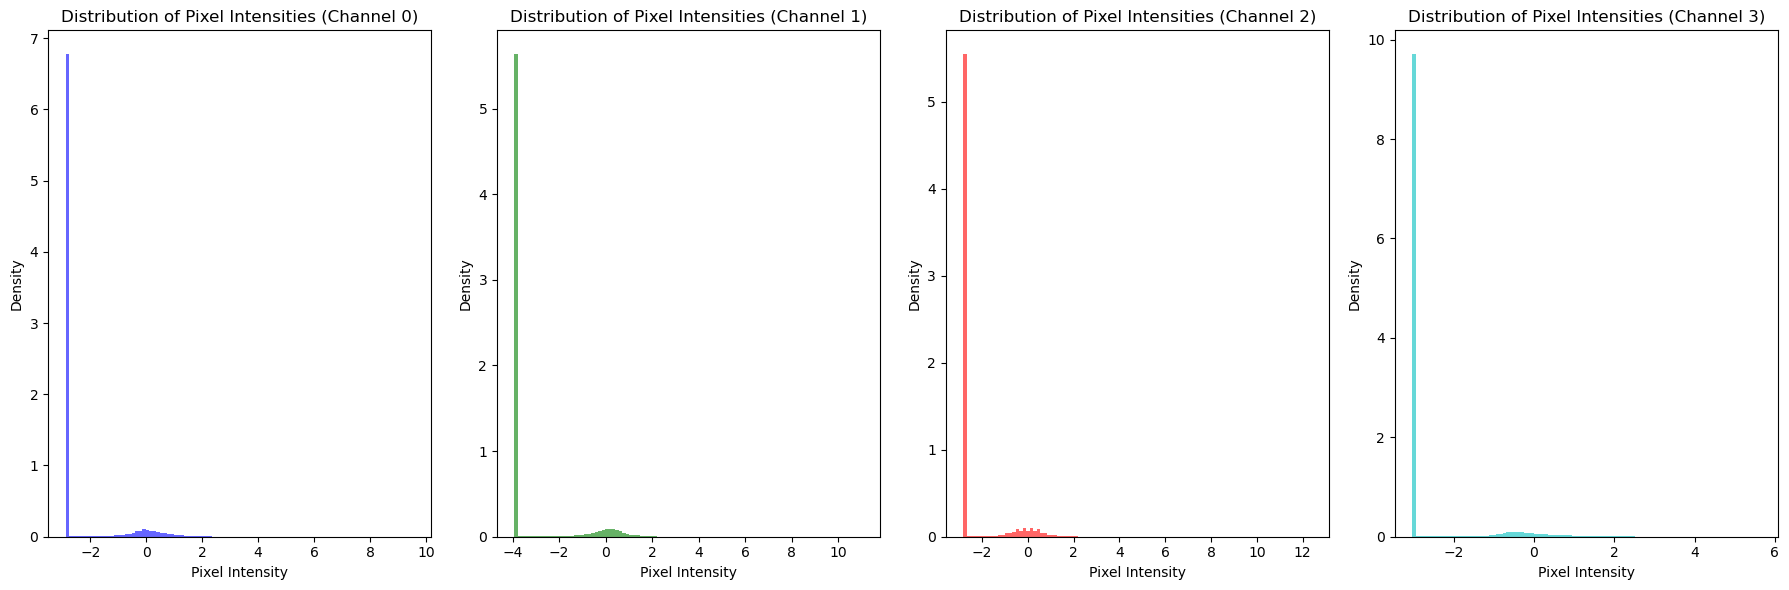

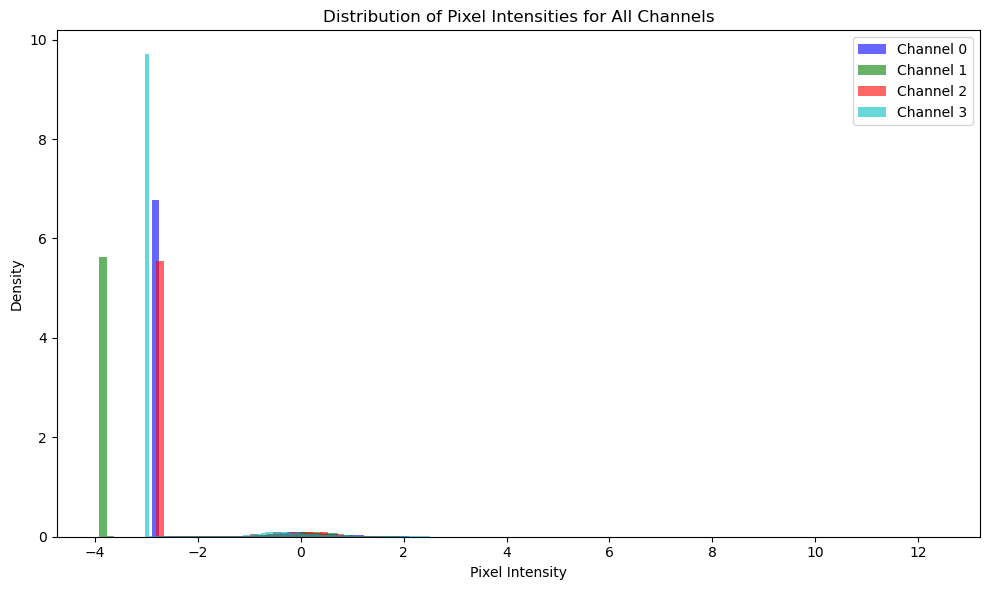

In [9]:
# Load a NIfTI image from the WMH dataset
nifti_image_path = 'data/BRATS/Images/BRATS_019_normed_on_mask.nii.gz'
nifti_image = nib.load(nifti_image_path)
nifti_image_data = nifti_image.get_fdata()

nifti_image_data = np.transpose(nifti_image_data, (3, 0, 1, 2))

# Define colors for each channel
colors = ['b', 'g', 'r', 'c']

# Plot the pixel intensities for each channel
fig, axes = plt.subplots(1, nifti_image_data.shape[0], figsize=(18, 6))

for i in range(nifti_image_data.shape[0]):
    pixel_intensities = nifti_image_data[i].flatten()
    axes[i].hist(pixel_intensities, bins=100, density=True, alpha=0.6, color=colors[i])
    axes[i].set_title(f'Distribution of Pixel Intensities (Channel {i})')
    axes[i].set_xlabel('Pixel Intensity')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


# Plot all pixel intensity distributions on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(nifti_image_data.shape[0]):
    pixel_intensities = nifti_image_data[i].flatten()
    ax.hist(pixel_intensities, bins=100, density=True, alpha=0.6, color=colors[i], label=f'Channel {i}')

ax.set_title('Distribution of Pixel Intensities for All Channels')
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()


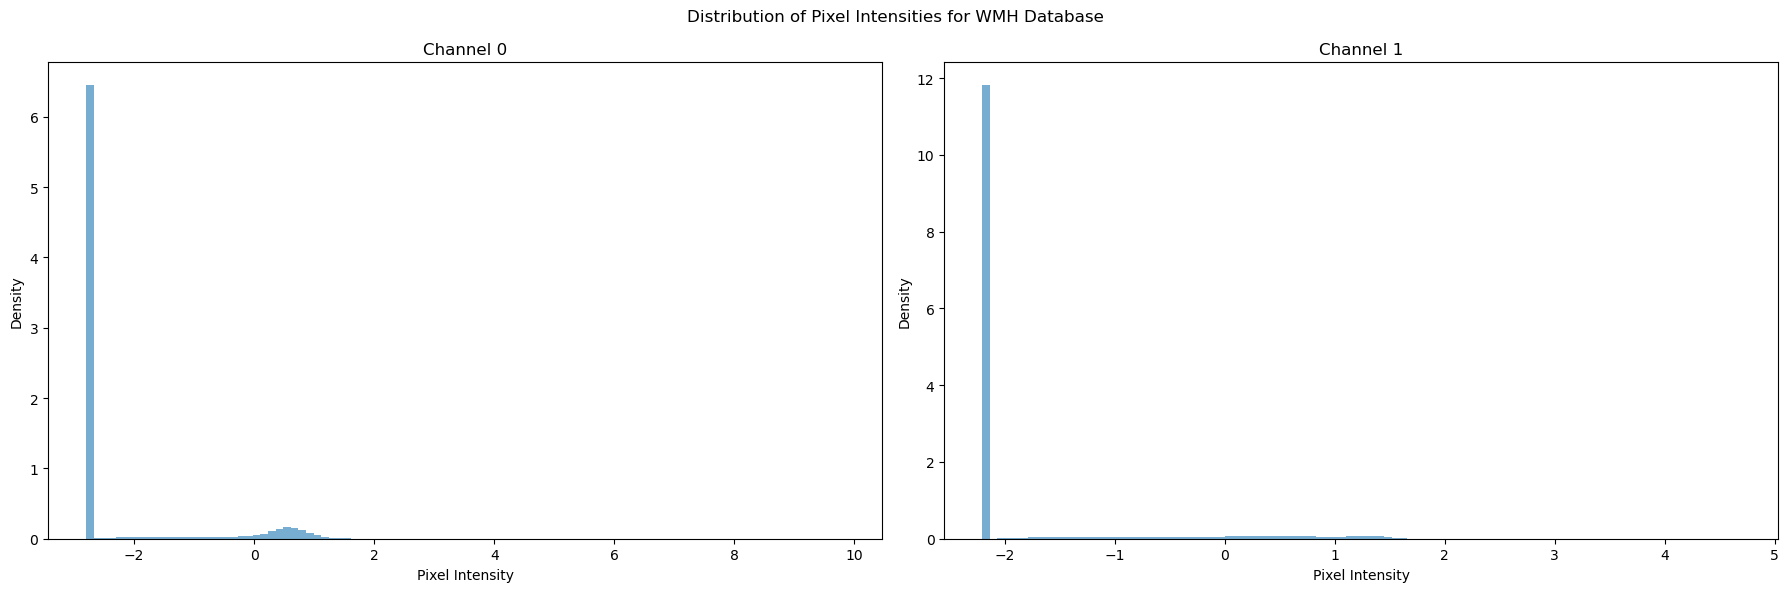

FileNotFoundError: No such file or no access: 'data/WMH/Images/train_24_u.nii.gz'

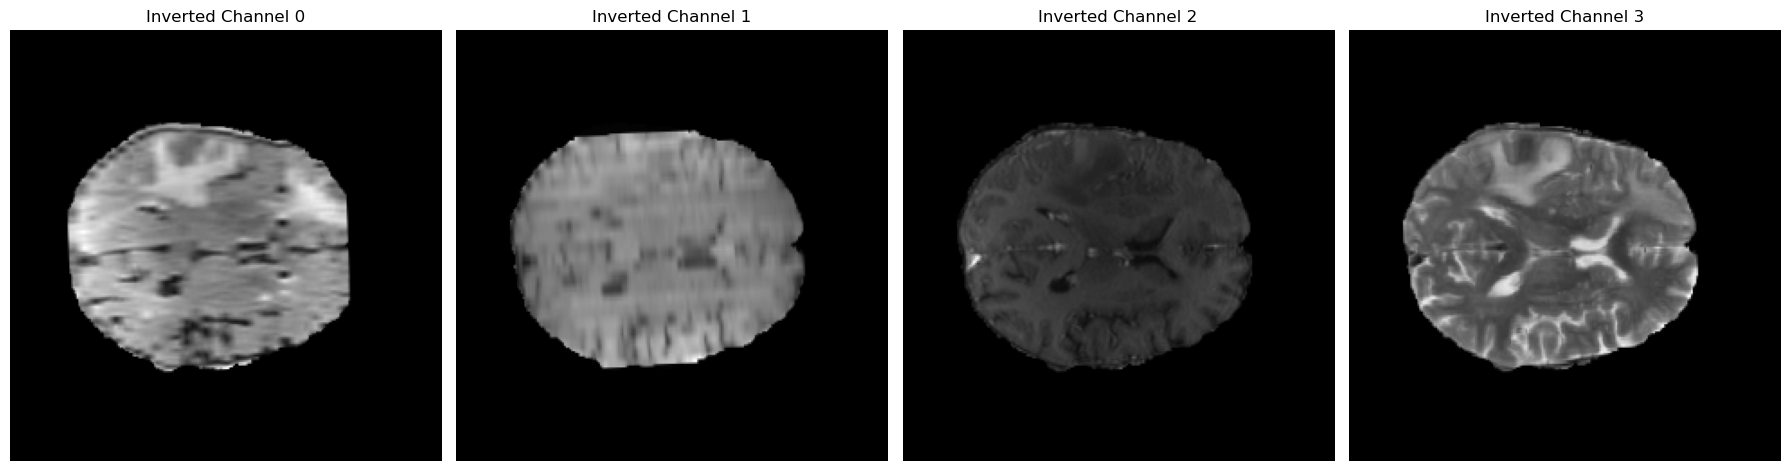

(4, 240, 240, 155)
[[[[1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   ...
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]]

  [[1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   ...
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]
   [1.03568935 1.03568935 1.03568935 ... 1.03568935 1.03568935
    1.03568935]]

  [[1.03568935 

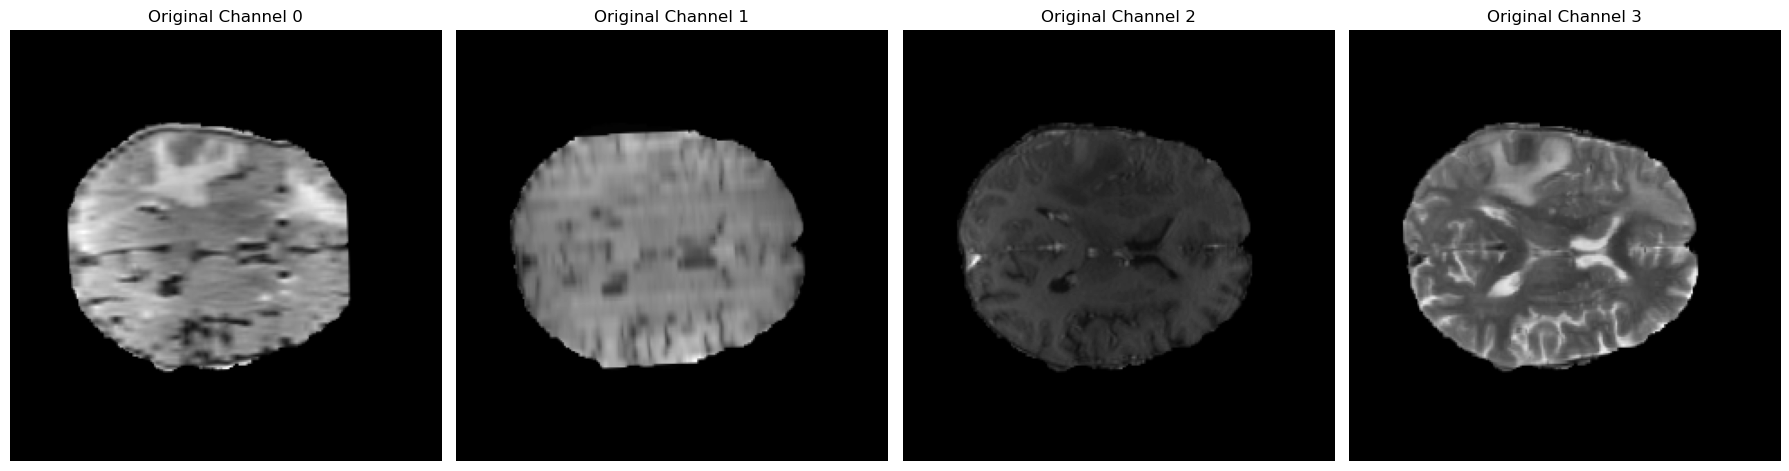

In [10]:
# invert the pixel intensities in an image

#load up image
nifti_image_path = 'data/BRATS/Images/BRATS_019_normed_on_mask.nii.gz'
nifti_image = nib.load(nifti_image_path)
nifti_image_data = nifti_image.get_fdata()
nifti_image_data = np.transpose(nifti_image_data, (3, 0, 1, 2))

# Invert the pixel intensities
nifti_image_data = np.max(nifti_image_data) - nifti_image_data

# Plot the inverted image
import matplotlib.pyplot as plt

# Define the slice index for visualization
slice_index = 80

# Invert the pixel intensities only for non-zero values
nifti_image_data[nifti_image_data != 0] = np.max(nifti_image_data) - nifti_image_data[nifti_image_data != 0]
# Get the number of channels
num_channels = nifti_image_data.shape[0]

# Create a subplot for each channel
fig, axes = plt.subplots(1, num_channels, figsize=(18, 6))

# Plot each channel
for i in range(num_channels):
    axes[i].imshow(nifti_image_data[i, :, :, slice_index], cmap="gray")
    axes[i].set_title(f'Inverted Channel {i}')
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print(nifti_image_data.shape)
# invert the pixel intensities 
print(nifti_image_data)

# Plot the initial channels of the original image before inversion
fig, axes = plt.subplots(1, num_channels, figsize=(18, 6))

for i in range(num_channels):
    axes[i].imshow(nifti_image_data[i, :, :, slice_index], cmap="gray")
    axes[i].set_title(f'Original Channel {i}')
    axes[i].axis("off")

plt.tight_layout()
plt.show()




lam: 0.5104820823112836
Mixed Masked Image Tensor: tensor([[[[-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          ...,
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.]],

         [[-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          ...,
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.]],

         [[-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          ...,
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.],
          [-0., -0., -0.,  ..., -0., -0., -0.]],

         ...,

         [[-0., -0.

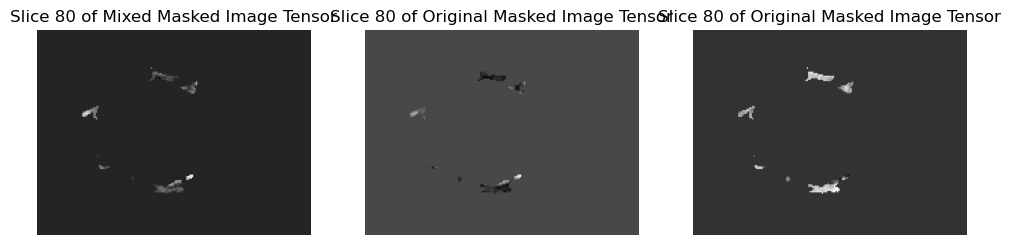

In [11]:
# perform mixup of the tumor masks
# sample from  different distributiona nd apply to the tumor masks.


label_path = 'data/MSSEG/Labels/test_c03_p01.nii.gz'
label_nifti = nib.load(label_path)
label_data = label_nifti.get_fdata()

# Convert the label data to a tensor
label_tensor = torch.tensor(label_data, dtype=torch.float32).unsqueeze(0)

# Apply the label as a mask to the image (so get label mask for each modality)
masked_image_tensor = wmh_image_tensor1[:2,...] * label_tensor

# Mixup between the masked regions of the images
mixed_masked_image_tensor, lam = mixup_data(masked_image_tensor, alpha=3)



#plot the original 

# Print the mixed masked image tensor
print("Mixed Masked Image Tensor:", mixed_masked_image_tensor)

# Define the slice index
slice_index = 80

# Visualize the mixed masked image tensor
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Plot the slice of the mixed masked image tensor
axes[0].imshow(mixed_masked_image_tensor[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[0].set_title(f"Slice {slice_index} of Mixed Masked Image Tensor")
axes[0].axis("off")

# Plot the slice of the original masked image tensor
axes[1].imshow(masked_image_tensor[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[1].set_title(f"Slice {slice_index} of Original Masked Image Tensor")
axes[1].axis("off")

axes[2].imshow(masked_image_tensor[1, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[2].set_title(f"Slice {slice_index} of Original Masked Image Tensor")
axes[2].axis("off")


plt.show()



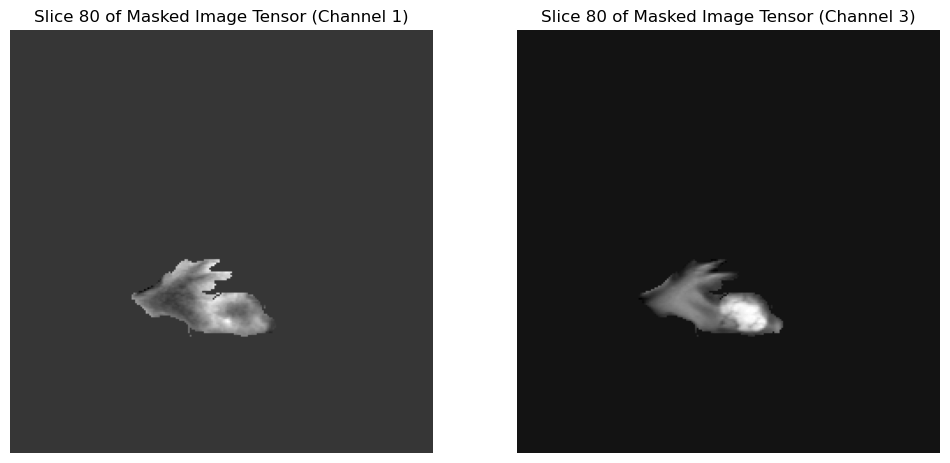

lam: 0.8811991293011429
lam: 0.6739440294702641


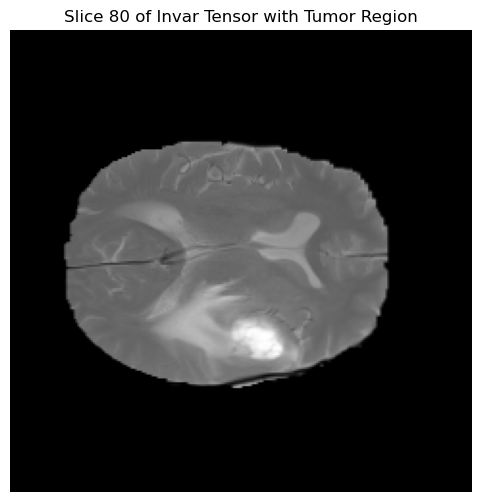

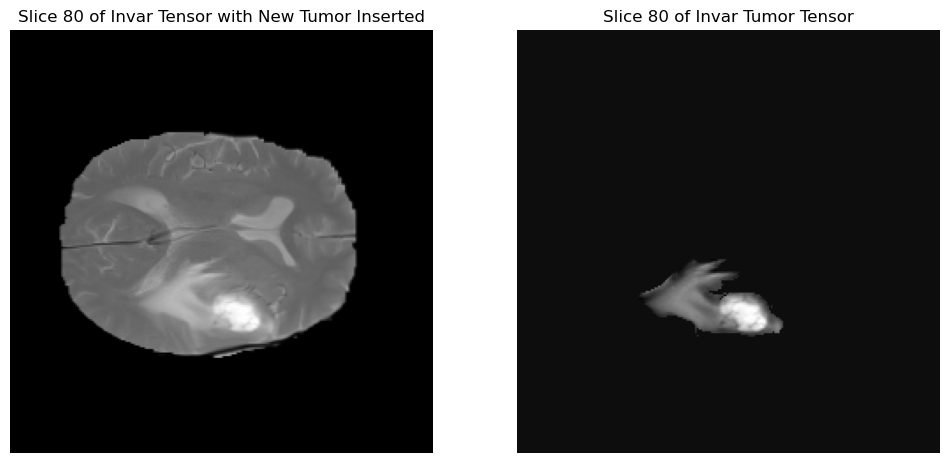

invar: tensor([[[[-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          ...,
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970]],

         [[-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          ...,
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970]],

         [[-3.0970, -3.0970, -3.0970,  ..., -3.0970, -3.0970, -3.0970],
          [-3.0970, -3.

In [12]:
import random

# Assuming batch_img and batch_label_data are defined
# Create a sample batch_img and batch_label_data for testing
# Load a NIfTI image and label from the WMH dataset
wmh_image_path = 'data/BRATS/Images/BRATS_001_normed_on_mask.nii.gz'
wmh_image_nifti = nib.load(wmh_image_path)
wmh_image_data = wmh_image_nifti.get_fdata()

label_path = 'data/BRATS/Labels/BRATS_001merged.nii.gz'
label_nifti = nib.load(label_path)
label_data = label_nifti.get_fdata()

# Convert the NIfTI image and label data to tensors
batch_img = torch.tensor(wmh_image_data, dtype=torch.float32).unsqueeze(0)
batch_label_data = torch.tensor(label_data, dtype=torch.float32).unsqueeze(0)
# Permute the batch_img and batch_label_data tensors to have batch size first
batch_img = batch_img.permute(0, 4, 1, 2, 3)

# Set mixup to True for testing
mixup = True

# Test the code snippet with one data sample
if mixup:
    channel_add = random.sample(list(np.arange(batch_img.size(1))), 2)
    label_channel = random.sample(list(np.arange(batch_img.size(1))), 2)

    masked_image_tensor = (batch_img[:, channel_add, :, :,:] * batch_label_data[0, :, :, :])

    #######################################################
    # Define the slice index for visualization
    slice_index =80

    # Visualize the masked image tensor
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the slice of the masked image tensor for each channel
    axes[0].imshow(masked_image_tensor[0, 0, :, :, slice_index].cpu().numpy(), cmap="gray")
    axes[0].set_title(f"Slice {slice_index} of Masked Image Tensor (Channel {channel_add[0]})")
    axes[0].axis("off")

    axes[1].imshow(masked_image_tensor[0, 1, :, :, slice_index].cpu().numpy(), cmap="gray")
    axes[1].set_title(f"Slice {slice_index} of Masked Image Tensor (Channel {channel_add[1]})")
    axes[1].axis("off")

    plt.show()
    ######################################################
    invar_tumor, _ = mixup_data(masked_image_tensor.squeeze(0), 2)
    invar, _ = mixup_data(batch_img[0, channel_add, :, :, :], 3)



    # Ensure invar is updated correctly
    
    invar[invar_tumor > 0] = invar_tumor[invar_tumor > 0]

    # Ensure invar and invar_tumor are different
    assert not torch.equal(invar, invar_tumor), "invar and invar_tumor should be different after modification"

    # Visualize the tumor region from invar tensor
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(invar[0, :, :, slice_index].cpu().numpy(), cmap="gray")
    ax.set_title(f"Slice {slice_index} of Invar Tensor with Tumor Region")
    ax.axis("off")

    plt.show()

    

    if not torch.equal(invar[invar_tumor > 0], invar_tumor[invar_tumor > 0]):
        raise AssertionError("Invariant channel does not match the expected values.")

    #######################################################
    # Define the slice index for visualization

    # Visualize the invar tensor with new tumor inserted
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the slice of the invar tensor
    axes[0].imshow(invar[0, :, :, slice_index].cpu().numpy(), cmap="gray")
    axes[0].set_title(f"Slice {slice_index} of Invar Tensor with New Tumor Inserted")
    axes[0].axis("off")

    # Plot the slice of the invar_tumor tensor
    axes[1].imshow(invar_tumor[0, :, :, slice_index].cpu().numpy(), cmap="gray")
    axes[1].set_title(f"Slice {slice_index} of Invar Tumor Tensor")
    axes[1].axis("off")

    plt.show()

    #######################################################

print("invar:", invar)
print("invar_tumor:", invar_tumor)


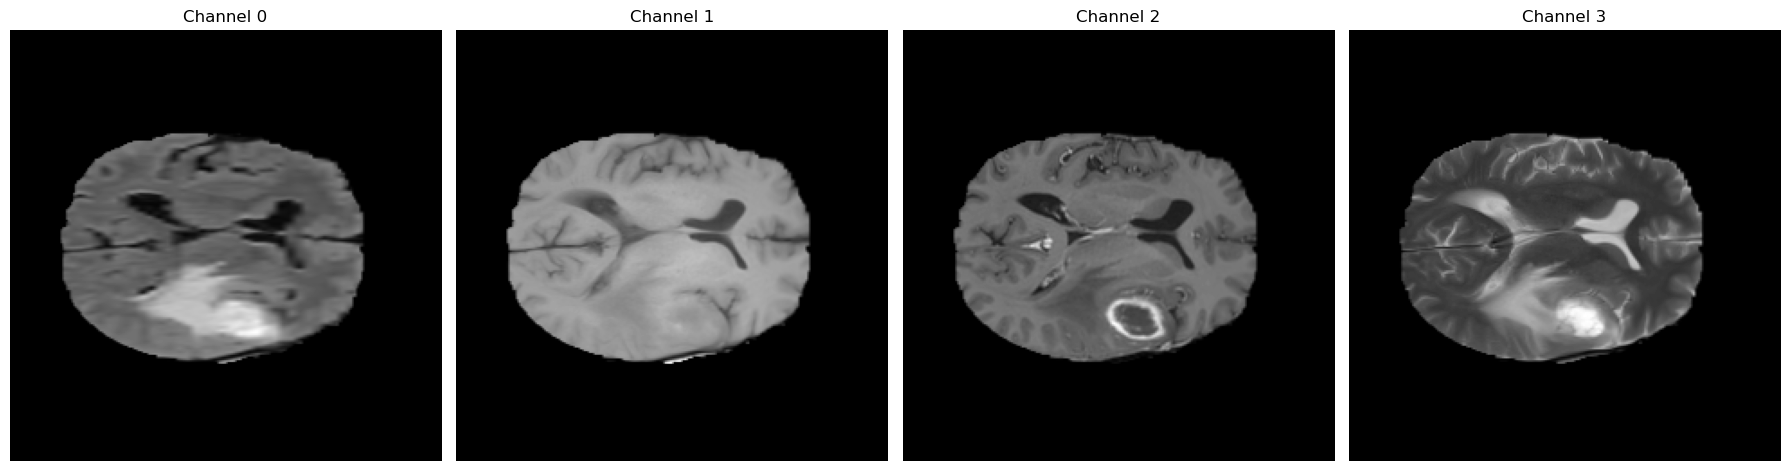

In [43]:
# Plot all channels for the given MRI tensor

import matplotlib.pyplot as plt


# Define the MRI tensor to plot
mri_tensor = batch_img.cpu()
# Define the slice index for visualization
slice_index = 80

# Get the number of channels
num_channels = mri_tensor.size(1)

# Create a subplot for each channel
fig, axes = plt.subplots(1, num_channels, figsize=(18, 6))

# Plot each channel
for i in range(num_channels):
    axes[i].imshow(mri_tensor[0, i, :, :, slice_index].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()



(240, 240, 155, 4)
(4, 240, 240, 155)


/tmp/ipykernel_184210/1288557551.py:60: RuntimeWarning: invalid value encountered in divide
  return reconstructed_image / patch_count


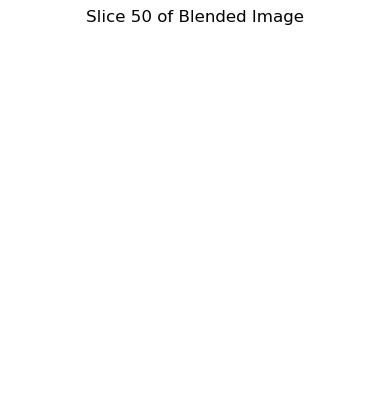

TypeError: Invalid shape (4, 240, 240, 155) for image data

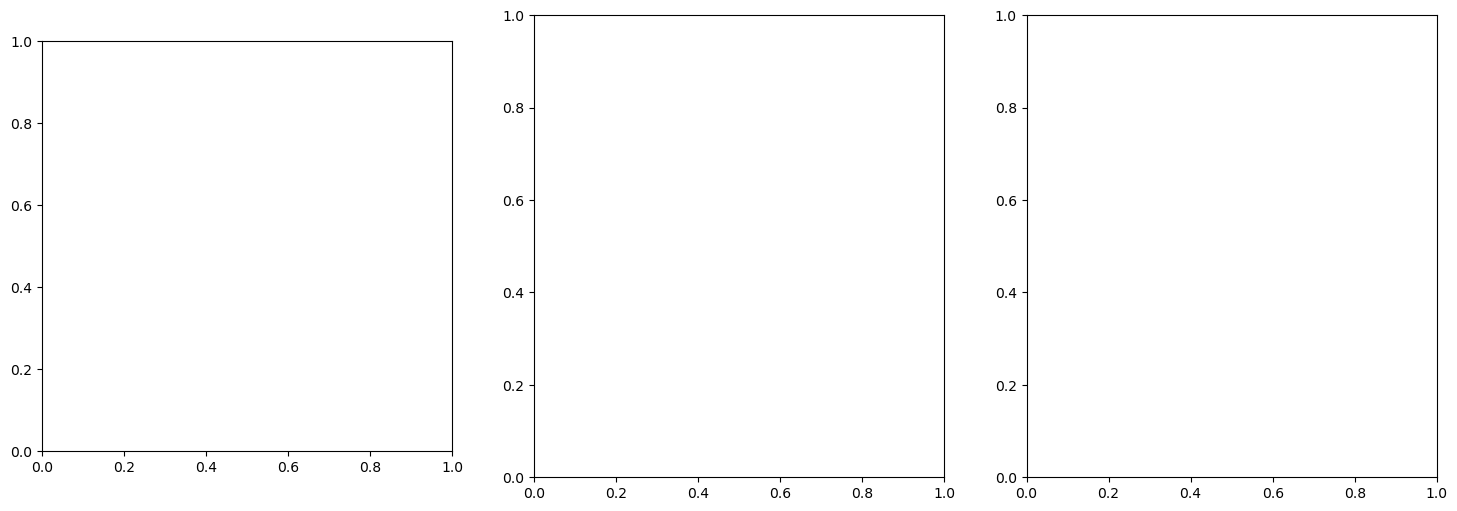

In [63]:



import nibabel as nib
import numpy as np
from skimage import filters, feature
from skimage.transform import resize
import matplotlib.pyplot as plt


# Load the two NIfTI images
nifti_image_path1 = 'data/BRATS/Images/BRATS_004_normed_on_mask.nii.gz'

nifti_image1 = nib.load(nifti_image_path1)

img1 = nifti_image1.get_fdata()
print(img1.shape)
img1 = np.transpose(img1, (3, 0, 1, 2))
img_1 = img1[0]
img2 = img1[1]

# Define the patch size and overlap
patch_size = 32
overlap = 4

# Function to extract patches from an image
def extract_patches(image, patch_size, overlap):
    patches = []
    step = patch_size - overlap
    for i in range(0, image.shape[0] - patch_size + 1, step):
        for j in range(0, image.shape[1] - patch_size + 1, step):
            patch = image[i:i + patch_size, j:j + patch_size]
            patches.append(patch)
    return patches

# Extract patches from both images
patches1 = extract_patches(img1, patch_size, overlap)
patches2 = extract_patches(img2, patch_size, overlap)

# Function to randomly select patches from two sets and blend them
def blend_patches(patches1, patches2, alpha):
    blended_patches = []
    for p1, p2 in zip(patches1, patches2):
        blended_patch = alpha * p1 + (1 - alpha) * p2
        blended_patches.append(blended_patch)
    return blended_patches

# Blend the patches
blended_patches = blend_patches(patches1, patches2, alpha)


# Function to reconstruct the image from patches
def reconstruct_image(patches, image_shape, patch_size, overlap):
    step = patch_size - overlap
    reconstructed_image = np.zeros(image_shape)
    patch_count = np.zeros(image_shape)
    patch_idx = 0
    for i in range(0, image_shape[0] - patch_size + 1, step):
        for j in range(0, image_shape[1] - patch_size + 1, step):
            reconstructed_image[i:i + patch_size, j:j + patch_size] += patches[patch_idx]
            patch_count[i:i + patch_size, j:j + patch_size] += 1
            patch_idx += 1
    return reconstructed_image / patch_count

# Reconstruct the blended image
blended_image = reconstruct_image(blended_patches, img1.shape, patch_size, overlap)
print(blended_image.shape)
# Select a slice to visualize
slice_index = 50

# Plot the selected slice of the blended image
plt.imshow(blended_image[0, :,:, slice_index], cmap='gray')
plt.title(f'Slice {slice_index} of Blended Image')
plt.axis('off')
plt.show()
# Plot the original and blended images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(blended_image, cmap='gray')
axes[2].set_title('Blended Image')
axes[2].axis('off')

plt.show()

In [ ]:
#plotting histogrmas of brain data point

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

# Load the NIfTI image
image_path = 'data/BRATS/Images/BRATS_002_normed_on_mask.nii.gz'
nifti_image = nib.load(image_path)
image_data = nifti_image.get_fdata()
print(image_data.shape)

# Assuming the image is 4D (x, y, z, channels), select the first channel for greyscale
greyscale_image = image_data[..., 3]

# Calculate the histogram of the positive and negative values separately
positive_values = greyscale_image[greyscale_image > 0]
negative_values = greyscale_image[greyscale_image < 0]
print(negative_values)

hist_positive, bin_edges_positive = np.histogram(positive_values, bins=256, range=(0, np.max(positive_values)))
hist_negative, bin_edges_negative = np.histogram(negative_values, bins=256, range=(np.min(negative_values), 0))
mean_value = np.mean(greyscale_image)

print("Mean value of all data:", mean_value)
# Add a vertical line at the mean value
plt.axvline(mean_value, color='green', linestyle='dashed', linewidth=1, label=f'Mean Value: {mean_value:.2f}')
# Plot the histograms on the same graph
plt.plot(bin_edges_positive[:-1], hist_positive, color='blue', label='Positive Values')
plt.plot(bin_edges_negative[:-1], hist_negative, color='red', label='Negative Values')

# Plot the histograms
plt.figure(figsize=(12, 6))

plt.plot(bin_edges_positive[:-1], hist_positive, color='blue', label='Positive Values')
plt.plot(bin_edges_negative[:-1], hist_negative, color='red', label='Negative Values')
plt.title('Histogram of Positive and Negative Values')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Find the most common value (mode) and the lowest value in the greyscale image


lowest_value = greyscale_image.min()


print("Lowest value:", lowest_value)


In [ ]:
## change pathologies and background contrast differetn ammounts 



